# EduPredict-XAI

## Step 16 — TabPFN Main Model

**Research Topic:** Student Performance Prediction Using Explainable AI

**Student:** Payal Pramod Pawar  
**Program:** MCA Sem 3  
**Guide:** Mrs. Shaesta Mujawar

### Objective

Train TabPFN as the main research model for student performance prediction.

The performance of TabPFN will be compared with the baseline models:

- CatBoost
- XGBoost
- LightGBM

Evaluation metrics:

- MAE
- RMSE
- R²

In [2]:
# Environment Setup
from pathlib import Path
from dotenv import load_dotenv
import os
import sys

# Project root
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / ".env").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Load .env
ENV_PATH = PROJECT_ROOT / ".env"
load_dotenv(ENV_PATH, override=True)

# Get token
token = os.getenv("TABPFN_TOKEN")

print("Python:")
print(sys.executable)

print("\n.env path:")
print(ENV_PATH)

print("\nTabPFN token detected:", bool(token))

if token:
    print("Token length:", len(token))
    print("Contains ellipsis:", "…" in token)

Python:
d:\MCA Sem 3\RP\EduPredict-XAI\.venv\Scripts\python.exe

.env path:
d:\MCA Sem 3\RP\EduPredict-XAI\.env

TabPFN token detected: True
Token length: 53
Contains ellipsis: False


In [3]:
# Import Libraries
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tabpfn import TabPFNRegressor

print("Libraries imported successfully.")

Libraries imported successfully.


d:\MCA Sem 3\RP\EduPredict-XAI\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load API Token
# Find the project root
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / ".env").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / ".env").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

print("Project root:")
print(PROJECT_ROOT)


Project root:
d:\MCA Sem 3\RP\EduPredict-XAI


In [5]:
# Check Python Environment
print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
d:\MCA Sem 3\RP\EduPredict-XAI\.venv\Scripts\python.exe

Python version:
3.10.9 (tags/v3.10.9:1dd9be6, Dec  6 2022, 20:01:21) [MSC v.1934 64 bit (AMD64)]


In [6]:
# Check Environment
import sys
import torch
import tabpfn

print("Python:")
print(sys.executable)

print("\nPyTorch version:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

print("\nTabPFN version:")
print(getattr(tabpfn, "__version__", "Unknown"))

Python:
d:\MCA Sem 3\RP\EduPredict-XAI\.venv\Scripts\python.exe

PyTorch version:
2.5.1+cpu

CUDA available:
False

TabPFN version:
8.3.0


In [7]:
# Project Paths
PROCESSED_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed"
)

RESULTS_PATH = (
    PROJECT_ROOT / "results"
)

MODELS_PATH = (
    PROJECT_ROOT / "models"
)

RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed data:")
print(PROCESSED_DATA_PATH)

print("\nResults:")
print(RESULTS_PATH)

print("\nModels:")
print(MODELS_PATH)


Processed data:
d:\MCA Sem 3\RP\EduPredict-XAI\data\processed

Results:
d:\MCA Sem 3\RP\EduPredict-XAI\results

Models:
d:\MCA Sem 3\RP\EduPredict-XAI\models


In [8]:
# Load Feature-Engineered Dataset
DATA_PATH = (
    PROCESSED_DATA_PATH /
    "student_performance_feature_engineered.csv"
)

print("Loading dataset:")
print(DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")

print("Shape:", df.shape)

display(df.head())

Loading dataset:
d:\MCA Sem 3\RP\EduPredict-XAI\data\processed\student_performance_feature_engineered.csv

Dataset loaded successfully.
Shape: (1000, 10)


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3
3,Male,2.6,77.5,8.0,High School,Yes,Yes,No,85.1,83.8
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3


In [9]:
# Display All Columns
print("Dataset columns:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset columns:
1. gender
2. study_time_hours
3. attendance_percent
4. sleep_hours
5. parental_education
6. internet_access
7. extracurricular_activities
8. part_time_job
9. previous_grade
10. final_exam_score


In [10]:
# Set the target
TARGET = "final_exam_score"

print("Target column:", TARGET)

if TARGET in df.columns:
    print("Target found successfully.")
else:
    raise KeyError(
        f"{TARGET} is not present in the dataset."
    )

Target column: final_exam_score
Target found successfully.


In [11]:
# Separate X and y 
X = df.drop(
    columns=[TARGET]
).copy()

y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")

for i, feature in enumerate(X.columns, start=1):
    print(f"{i}. {feature}")

X shape: (1000, 9)
y shape: (1000,)

Features:
1. gender
2. study_time_hours
3. attendance_percent
4. sleep_hours
5. parental_education
6. internet_access
7. extracurricular_activities
8. part_time_job
9. previous_grade


In [12]:
# Leakage Check
print("=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)

print("Target:", TARGET)

print(
    "final_grade present in X:",
    "final_grade" in X.columns
)

print(
    "previous_grade present in X:",
    "previous_grade" in X.columns
)

DATA LEAKAGE CHECK
Target: final_exam_score
final_grade present in X: False
previous_grade present in X: True


In [13]:
# Check Missing Values 
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in X:
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
dtype: int64

Missing values in target:
0


In [14]:
# Identify Data Types
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Categorical features:
['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job']

Numerical features:
['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade']


In [15]:
# Prepare Categorical Features
X_tabpfn = X.copy()

for column in categorical_features:
    X_tabpfn[column] = X_tabpfn[column].astype("category")

print("TabPFN input prepared.")

display(
    X_tabpfn.dtypes.to_frame(
        name="Data Type"
    )
)

TabPFN input prepared.


,Data Type
gender,category
study_time_hours,float64
attendance_percent,float64
sleep_hours,float64
parental_education,category
internet_access,category
extracurricular_activities,category
part_time_job,category
previous_grade,float64


In [16]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tabpfn,
    y,
    test_size=0.20,
    random_state=42
)

print("Train/Test split completed.")

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_test :", y_test.shape)

Train/Test split completed.

X_train: (800, 9)
X_test : (200, 9)

y_train: (800,)
y_test : (200,)


In [17]:
# Verify the Split
print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

print(
    "\nTotal rows:",
    len(X_train) + len(X_test)
)

Training rows: 800
Testing rows : 200

Total rows: 1000


In [18]:
# Reinitialize TabPFN
tabpfn_model = TabPFNRegressor(
    device="cpu",
    random_state=42,
    show_progress_bar=True
)

print("TabPFNRegressor initialized successfully.")

TabPFNRegressor initialized successfully.


In [19]:
print("=" * 60)
print("STARTING TABPFN TRAINING")
print("=" * 60)

tabpfn_model.fit(
    X_train,
    y_train
)

print("\nTabPFN training completed successfully.")

STARTING TABPFN TRAINING

TabPFN training completed successfully.


In [20]:
# Save fitted TabPFN object for XAI notebook
import pickle

TABPFN_PKL_PATH = (
    PROJECT_ROOT
    / "models"
    / "tabpfn_fitted_model.pkl"
)

with open(TABPFN_PKL_PATH, "wb") as f:
    pickle.dump(
        tabpfn_model,
        f
    )

print("Fitted TabPFN model saved successfully!")
print(TABPFN_PKL_PATH)

Fitted TabPFN model saved successfully!
d:\MCA Sem 3\RP\EduPredict-XAI\models\tabpfn_fitted_model.pkl


In [42]:
# Generate Predictions
print("Generating predictions...")

y_pred_tabpfn = tabpfn_model.predict(
    X_test
)

print("Predictions generated successfully.")
print(
    "Number of predictions:",
    len(y_pred_tabpfn)
)

Generating predictions...


TabPFN inference: 100%|██████████| 8/8 [00:23<00:00,  2.96s/estimator]

Predictions generated successfully.
Number of predictions: 200


In [43]:
# Actual vs Predicted Table
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_tabpfn
})

prediction_results["Absolute_Error"] = (
    np.abs(
        prediction_results["Actual"]
        -
        prediction_results["Predicted"]
    )
)

display(
    prediction_results.head(10)
)

,Actual,Predicted,Absolute_Error
0,71.8,78.146301,6.346301
1,66.6,72.488831,5.888831
2,62.9,73.430115,10.530115
3,95.2,92.228600,2.971400
4,90.2,89.471405,0.728595
5,63.6,69.941772,6.341772
6,96.8,94.276123,2.523877
7,77.9,73.064026,4.835974
8,66.5,71.654114,5.154114
9,59.7,63.745628,4.045628


In [44]:
# MAE
tabpfn_mae = mean_absolute_error(
    y_test,
    y_pred_tabpfn
)

print(
    f"TabPFN MAE: {tabpfn_mae:.4f}"
)

TabPFN MAE: 4.9842


In [46]:
# RMSE
tabpfn_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tabpfn
    )
)

print(
    f"TabPFN RMSE: {tabpfn_rmse:.4f}"
)

TabPFN RMSE: 6.4538


In [47]:
# R²
tabpfn_r2 = r2_score(
    y_test,
    y_pred_tabpfn
)

print(
    f"TabPFN R²: {tabpfn_r2:.4f}"
)

TabPFN R²: 0.6130


In [48]:
# TabPFN Performance Summary
print("=" * 60)
print("TABPFN PERFORMANCE")
print("=" * 60)

print(f"MAE  : {tabpfn_mae:.4f}")
print(f"RMSE : {tabpfn_rmse:.4f}")
print(f"R²   : {tabpfn_r2:.4f}")

TABPFN PERFORMANCE
MAE  : 4.9842
RMSE : 6.4538
R²   : 0.6130


In [49]:
# Save TabPFN Predictions
prediction_path = (
    RESULTS_PATH /
    "tabpfn_predictions.csv"
)

prediction_results.to_csv(
    prediction_path,
    index=False
)

print("TabPFN predictions saved successfully:")
print(prediction_path)


TabPFN predictions saved successfully:
d:\MCA Sem 3\RP\EduPredict-XAI\results\tabpfn_predictions.csv


In [50]:
# Load Baseline Results
baseline_results_path = (
    RESULTS_PATH /
    "baseline_model_results.csv"
)

if not baseline_results_path.exists():
    print("Baseline result file was not found.")
    print("\nFiles currently inside results folder:")

    for file in RESULTS_PATH.iterdir():
        print("-", file.name)

else:
    baseline_results = pd.read_csv(
        baseline_results_path
    )

    print("Baseline results loaded:")
    display(baseline_results)

Baseline results loaded:


,Model,MAE,RMSE,R2
0,CatBoost,5.346276,6.810513,0.569078
1,XGBoost,5.796504,7.331855,0.500580
2,LightGBM,6.082377,7.554699,0.469760


In [51]:
# Add TabPFN to Model Comparison
tabpfn_result = pd.DataFrame([
    {
        "Model": "TabPFN",
        "MAE": tabpfn_mae,
        "RMSE": tabpfn_rmse,
        "R2": tabpfn_r2
    }
])

all_model_results = pd.concat(
    [
        baseline_results,
        tabpfn_result
    ],
    ignore_index=True
)

print("Complete model results:")
display(all_model_results)

Complete model results:


,Model,MAE,RMSE,R2
0,CatBoost,5.346276,6.810513,0.569078
1,XGBoost,5.796504,7.331855,0.500580
2,LightGBM,6.082377,7.554699,0.469760
3,TabPFN,4.984223,6.453816,0.613035


In [52]:
# Model Ranking
comparison_results = (
    all_model_results
    .sort_values(
        by="RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

print("=" * 60)
print("MODEL PERFORMANCE RANKING")
print("=" * 60)

display(comparison_results)

MODEL PERFORMANCE RANKING


,Model,MAE,RMSE,R2
0,TabPFN,4.984223,6.453816,0.613035
1,CatBoost,5.346276,6.810513,0.569078
2,XGBoost,5.796504,7.331855,0.500580
3,LightGBM,6.082377,7.554699,0.469760


In [53]:
# Find Best Model
best_model = comparison_results.iloc[0]

print("=" * 60)
print("BEST MODEL BASED ON RMSE")
print("=" * 60)

print(
    "Model:",
    best_model["Model"]
)

print(
    f"RMSE: {best_model['RMSE']:.4f}"
)

print(
    f"MAE : {best_model['MAE']:.4f}"
)

print(
    f"R²  : {best_model['R2']:.4f}"
)

BEST MODEL BASED ON RMSE
Model: TabPFN
RMSE: 6.4538
MAE : 4.9842
R²  : 0.6130


In [54]:
# Save Model Comparison
comparison_path = (
    RESULTS_PATH /
    "all_model_comparison.csv"
)

comparison_results.to_csv(
    comparison_path,
    index=False
)

print("Complete model comparison saved:")
print(comparison_path)

Complete model comparison saved:
d:\MCA Sem 3\RP\EduPredict-XAI\results\all_model_comparison.csv


In [55]:
# Save Fitted TabPFN
from tabpfn.model_loading import save_fitted_tabpfn_model

tabpfn_model_path = (
    MODELS_PATH /
    "tabpfn_regressor.tabpfn_fit"
)

save_fitted_tabpfn_model(
    tabpfn_model,
    tabpfn_model_path
)

print("Fitted TabPFN model saved successfully:")
print(tabpfn_model_path)

Fitted TabPFN model saved successfully:
d:\MCA Sem 3\RP\EduPredict-XAI\models\tabpfn_regressor.tabpfn_fit


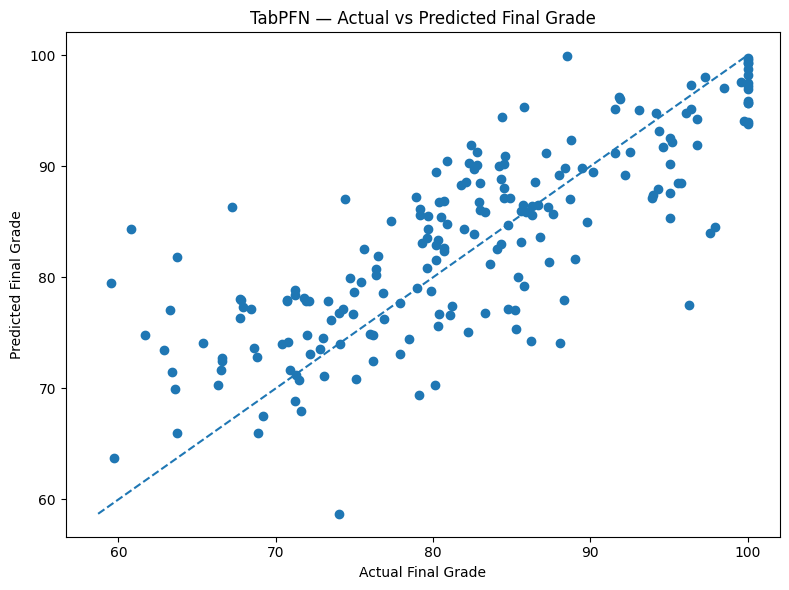

In [56]:
# Actual vs Predicted Graph
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_tabpfn
)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")

plt.title(
    "TabPFN — Actual vs Predicted Final Grade"
)

min_value = min(
    y_test.min(),
    y_pred_tabpfn.min()
)

max_value = max(
    y_test.max(),
    y_pred_tabpfn.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [ ]:
# Final Step 16 Summary
print("=" * 70)
print("STEP 16 — TABPFN COMPLETED")
print("=" * 70)

print("\nTabPFN Performance:")

print(f"MAE  : {tabpfn_mae:.4f}")
print(f"RMSE : {tabpfn_rmse:.4f}")
print(f"R²   : {tabpfn_r2:.4f}")

print("\nFiles created:")

print("✓ tabpfn_predictions.csv")
print("✓ all_model_comparison.csv")
print("✓ tabpfn_regressor.tabpfn_fit")


STEP 16 — TABPFN COMPLETED

TabPFN Performance:
MAE  : 4.9842
RMSE : 6.4538
R²   : 0.6130

Files created:
✓ tabpfn_predictions.csv
✓ all_model_comparison.csv
✓ tabpfn_regressor.tabpfn_fit

Step 16 completed successfully.
